In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from math import cos,sin,acos,asin
from matplotlib.colors import TwoSlopeNorm
import yt

In [2]:
#to display inside the notebook!
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
mpl.rc('image', cmap='nipy_spectral')
%matplotlib inline
%config InlineBackend.figure_format = "retina"
import matplotlib.font_manager as font_manager
from matplotlib.ticker import StrMethodFormatter
# print(font_manager.findSystemFonts(fontpaths=None, fontext='otf'))
font_dir = ['/home/pag/Downloads']
for font in font_manager.findSystemFonts(font_dir):
    font_manager.fontManager.addfont(font)
plt.rcParams['font.sans-serif'] = "Latin Modern Roman"
# Then, "ALWAYS use sans-serif fonts"
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['mathtext.fontset'] = "stix"
# if fonts are missing install the latin family in the font directory (use function below to find the system directory)

scale=1
SMALL_SIZE = 25*scale
MEDIUM_SIZE = 30*scale
BIGGER_SIZE = 35*scale

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [3]:
# ------------------------------------------------------------
# Reflectometry cutoff contour selection
# ------------------------------------------------------------

f_probe_Hz = 40e9          # chosen microwave frequency
cutoff_mode = "O"            # "O", "X_R", or "X_L"
read_stride = 1
plot_stride = 5

omega_probe = 2.0 * np.pi * f_probe_Hz

In [4]:
plotfile = Path("/mnt/c/Users/Pierre Gourdain/shared/data/outputs/FDTD_solver/plt00015")

ds = yt.load(str(plotfile))
ds

yt : [INFO     ] 2026-05-29 06:28:22,438 Parameters: current_time              = 4.224706273703305e-08
yt : [INFO     ] 2026-05-29 06:28:22,439 Parameters: domain_dimensions         = [4444    1 1441]
yt : [INFO     ] 2026-05-29 06:28:22,440 Parameters: domain_left_edge          = [ 6.75000048e+00 -2.08189216e-04  2.00000003e-01]
yt : [INFO     ] 2026-05-29 06:28:22,441 Parameters: domain_right_edge         = [8.60000038e+00 2.08189216e-04 8.00000012e-01]


BoxlibDataset: /mnt/c/Users/Pierre Gourdain/shared/data/outputs/FDTD_solver/plt00015

In [5]:
for f in ds.field_list:
    print(f)

('boxlib', 'Bx')
('boxlib', 'By')
('boxlib', 'Bz')
('boxlib', 'Eerr')
('boxlib', 'Ex')
('boxlib', 'Ey')
('boxlib', 'Ez')
('boxlib', 'Hx')
('boxlib', 'Hy')
('boxlib', 'Hz')
('boxlib', 'Jx')
('boxlib', 'Jy')
('boxlib', 'Jz')
('boxlib', 'Te')
('boxlib', 'ne')
('boxlib', 'nu')
('boxlib', 'rho')


In [6]:
field_type = "boxlib"

E_fields = [
    (field_type, "Ex"),
    (field_type, "Ey"),
    (field_type, "Ez"),
]

H_fields = [
    (field_type, "Hx"),
    (field_type, "Hy"),
    (field_type, "Hz"),
]

J_fields = [
    (field_type, "Jx"),
    (field_type, "Jy"),
    (field_type, "Jz"),
]

In [7]:
level = 0

left_edge = ds.domain_left_edge
right_edge = ds.domain_right_edge
dims = ds.domain_dimensions * (2**level)

cg = ds.covering_grid(
    level=level,
    left_edge=left_edge,
    dims=dims,
    num_ghost_zones=0,
)

print("left_edge  =", left_edge)
print("right_edge =", right_edge)
print("dims       =", dims)

left_edge  = [ 6.75000048e+00 -2.08189216e-04  2.00000003e-01] code_length
right_edge = [8.60000038e+00 2.08189216e-04 8.00000012e-01] code_length
dims       = [4444    1 1441]


In [8]:
left = np.asarray(left_edge.to_value())
right = np.asarray(right_edge.to_value())
dims_np = np.asarray(dims, dtype=int)

x = np.linspace(left[0], right[0], dims_np[0], endpoint=False)
y = np.linspace(left[1], right[1], dims_np[1], endpoint=False)
z = np.linspace(left[2], right[2], dims_np[2], endpoint=False)

dx = (right - left) / dims_np

x += 0.5 * dx[0]
y += 0.5 * dx[1]
z += 0.5 * dx[2]

print("x range:", x.min(), x.max(), "nx =", len(x))
print("y range:", y.min(), y.max(), "ny =", len(y))
print("z range:", z.min(), z.max(), "nz =", len(z))

x range: 6.75020862264101 8.599792235665875 nx = 4444
y range: 0.0 0.0 ny = 1
z range: 0.20020819174114157 0.7997918231600196 nz = 1441


In [9]:
axis = "y"      # "x", "y", or "z"
coord = None    # use None for domain center, or set e.g. coord = 0.0

In [10]:
def extract_2d_slice(data3d, axis="z", coord=None, stride=read_stride):
    """
    Extract a coordinate-aligned 2D plane from a 3D array, with optional striding.

    axis = "z" gives x-y plane at fixed z.
    axis = "y" gives x-z plane at fixed y.
    axis = "x" gives y-z plane at fixed x.

    data3d is assumed to have shape (nx, ny, nz).
    """

    if axis == "x":
        if coord is None:
            coord = 0.5 * (x.min() + x.max())
        idx = int(np.argmin(np.abs(x - coord)))

        yy = y[::stride]
        zz = z[::stride]

        data2d = data3d[idx, ::stride, ::stride].T
        X, Y = np.meshgrid(yy, zz, indexing="xy")

        xlabel = "y (m)"
        ylabel = "z (m)"
        actual_coord = x[idx]

    elif axis == "y":
        if coord is None:
            coord = 0.5 * (y.min() + y.max())
        idx = int(np.argmin(np.abs(y - coord)))

        xx = x[::stride]
        zz = z[::stride]

        data2d = data3d[::stride, idx, ::stride].T
        X, Y = np.meshgrid(xx, zz, indexing="xy")

        xlabel = "r (m)"
        ylabel = "z (m)"
        actual_coord = y[idx]

    elif axis == "z":
        if coord is None:
            coord = 0.5 * (z.min() + z.max())
        idx = int(np.argmin(np.abs(z - coord)))

        xx = x[::stride]
        yy = y[::stride]

        data2d = data3d[::stride, ::stride, idx].T
        X, Y = np.meshgrid(xx, yy, indexing="xy")

        xlabel = "r (m)"
        ylabel = "y (m)"
        actual_coord = z[idx]

    else:
        raise ValueError("axis must be 'x', 'y', or 'z'")

    return X, Y, data2d, xlabel, ylabel, actual_coord

In [11]:
R = extract_2d_slice(np.asarray(cg[("boxlib", "Ex")].to_ndarray()), axis=axis, coord=coord)[0]
Ex_2d = extract_2d_slice(np.asarray(cg[("boxlib", "Ex")].to_ndarray()), axis=axis, coord=coord)[2]
Ey_2d = extract_2d_slice(np.asarray(cg[("boxlib", "Ey")].to_ndarray()), axis=axis, coord=coord)[2]
Ez_2d = extract_2d_slice(np.asarray(cg[("boxlib", "Ez")].to_ndarray()), axis=axis, coord=coord)[2]

Hx_2d = extract_2d_slice(np.asarray(cg[("boxlib", "Hx")].to_ndarray()), axis=axis, coord=coord)[2]
Hy_2d = extract_2d_slice(np.asarray(cg[("boxlib", "Hy")].to_ndarray()), axis=axis, coord=coord)[2]
Hz_2d = extract_2d_slice(np.asarray(cg[("boxlib", "Hz")].to_ndarray()), axis=axis, coord=coord)[2]

Bx_2d = extract_2d_slice(np.asarray(cg[("boxlib", "Bx")].to_ndarray()), axis=axis, coord=coord)[2]
By_2d = extract_2d_slice(np.asarray(cg[("boxlib", "By")].to_ndarray()), axis=axis, coord=coord)[2]
Bz_2d = extract_2d_slice(np.asarray(cg[("boxlib", "Bz")].to_ndarray()), axis=axis, coord=coord)[2]

Jx_2d = extract_2d_slice(np.asarray(cg[("boxlib", "Jx")].to_ndarray()), axis=axis, coord=coord)[2]
Jy_2d = extract_2d_slice(np.asarray(cg[("boxlib", "Jy")].to_ndarray()), axis=axis, coord=coord)[2]
Jz_2d = extract_2d_slice(np.asarray(cg[("boxlib", "Jz")].to_ndarray()), axis=axis, coord=coord)[2]

ne_2d = extract_2d_slice(np.asarray(cg[("boxlib", "ne")].to_ndarray()), axis=axis, coord=coord)[2]
Te_2d = extract_2d_slice(np.asarray(cg[("boxlib", "Te")].to_ndarray()), axis=axis, coord=coord)[2]
rho_2d = extract_2d_slice(np.asarray(cg[("boxlib", "rho")].to_ndarray()), axis=axis, coord=coord)[2]
Eerr_2d = extract_2d_slice(np.asarray(cg[("boxlib", "Eerr")].to_ndarray()), axis=axis, coord=coord)[2]

Eerr_2d = np.log10(10**(Eerr_2d)+1e-18)


In [12]:
E = np.array([Ex_2d, Ey_2d, Ez_2d])
H = np.array([Hx_2d, Hy_2d, Hz_2d])
B = np.array([Bx_2d, By_2d, Bz_2d])
J = np.array([Jx_2d, Jy_2d, Jz_2d])

E_norm = np.sqrt(E[0]**2 + E[1]**2 + E[2]**2)
H_norm = np.sqrt(H[0]**2 + H[1]**2 + H[2]**2)
B_norm = np.sqrt(B[0]**2 + B[1]**2 + B[2]**2)
J_norm = np.sqrt(J[0]**2 + J[1]**2 + J[2]**2)



In [13]:
def get_field_3d(field):
    return np.asarray(cg[field].to_ndarray())


E_slices = []
H_slices = []
J_slices = []

for field in E_fields:
    data3d = get_field_3d(field)
    X, Y, data2d, xlabel, ylabel, actual_coord = extract_2d_slice(data3d, axis=axis, coord=coord)
    E_slices.append(data2d)

for field in H_fields:
    data3d = get_field_3d(field)
    X, Y, data2d, xlabel, ylabel, actual_coord = extract_2d_slice(data3d, axis=axis, coord=coord)
    H_slices.append(data2d)

for field in J_fields:
    data3d = get_field_3d(field)
    X, Y, data2d, xlabel, ylabel, actual_coord = extract_2d_slice(data3d, axis=axis, coord=coord)
    J_slices.append(data2d)

E = np.array(E_slices)
H = np.array(H_slices)
J = np.array(J_slices)

print("E shape:", E.shape)
print("H shape:", H.shape)
print("J shape:", J.shape)
print(f"Slice: {axis} = {actual_coord}")

E shape: (3, 1441, 4444)
H shape: (3, 1441, 4444)
J shape: (3, 1441, 4444)
Slice: y = 0.0


In [14]:
def add_reflectometry_contours(ax):
    """
    Overlay the locations where each characteristic frequency equals
    the launched microwave frequency.
    """

    contour_specs = [
        (omega_O,  r"O cutoff",  "-"),
        (omega_R,  r"R cutoff",  "--"),
        (omega_L,  r"L cutoff",  "-."),
        (omega_UH, r"UH res.",   ":"),
    ]

    handles = []

    for omega_field, label, linestyle in contour_specs:
        # Contour of omega_field - omega_probe = 0
        quantity = omega_field - omega_probe

        # Only draw if zero lies within the plotted range
        qmin = np.nanmin(quantity)
        qmax = np.nanmax(quantity)

        if qmin <= 0.0 <= qmax:
            cs = ax.contour(
                X,
                Y,
                quantity,
                levels=[0.0],
                colors="white",
                linestyles=linestyle,
                linewidths=2.0,
            )

            # Add inline labels directly on the contours
            ax.clabel(
                cs,
                fmt={0.0: label},
                inline=True,
                fontsize=16,
            )

            handles.append(cs.collections[0])

    return handles

In [15]:
# Physical constants
qe   = 1.602176634e-19
me0  = 9.1093837015e-31
eps0 = 8.8541878128e-12
c0   = 299792458.0

def compute_cutoff_frequency(ne, Te, Babs, mode="O"):
    """
    Return the selected cutoff angular frequency field.

    Assumptions:
      ne   in m^-3
      Te   in eV
      Babs in Tesla

    mode:
      "O"   : O-mode cutoff, omega = omega_pe
      "X_R" : X-mode right-hand cutoff
      "X_L" : X-mode left-hand cutoff
    """

    ne_safe = np.maximum(ne, 0.0)
    Te_safe = np.maximum(Te, 0.0)
    B_safe  = np.maximum(Babs, 0.0)

    me_rel = me0 * np.sqrt(
        1.0 + 5.0 * qe * Te_safe / (me0 * c0**2)
    )

    omega_pe = np.sqrt(qe**2 * ne_safe / (eps0 * me_rel))
    Omega_e = qe * B_safe / me_rel

    if mode.upper() == "O":
        return omega_pe

    elif mode.upper() in ["X_R", "R"]:
        return 0.5 * Omega_e + np.sqrt(0.25 * Omega_e**2 + omega_pe**2)

    elif mode.upper() in ["X_L", "L"]:
        return -0.5 * Omega_e + np.sqrt(0.25 * Omega_e**2 + omega_pe**2)

    elif mode.upper() in ["UH"]:
        return np.sqrt(Omega_e**2 + omega_pe**2)

    else:
        raise ValueError("mode must be 'O', 'X_R', 'X_L' or 'UH'")

In [16]:
def compute_reflectometry_frequencies(ne, Te, Babs):
    """
    Compute O-mode cutoff, X-mode R/L cutoffs, and upper-hybrid resonance.

    Assumptions:
      ne   in m^-3
      Te   in eV
      Babs in Tesla

    Returns angular frequencies in rad/s.
    """

    ne_safe = np.maximum(ne, 0.0)
    Te_safe = np.maximum(Te, 0.0)
    B_safe  = np.maximum(Babs, 0.0)

    # Relativistic thermal correction to electron mass.
    # If Te is in eV, qe * Te is energy in Joules.
    me_rel = me0 * np.sqrt(1.0 + 5.0 * qe * Te_safe / (me0 * c0**2))

    omega_pe = np.sqrt(qe**2 * ne_safe / (eps0 * me_rel))

    # Use positive electron cyclotron frequency magnitude
    Omega_e = qe * B_safe / me_rel

    # O-mode cutoff
    omega_O = omega_pe

    # X-mode right-hand and left-hand cutoffs
    omega_R = 0.5 * Omega_e + np.sqrt(0.25 * Omega_e**2 + omega_pe**2)
    omega_L = -0.5 * Omega_e + np.sqrt(0.25 * Omega_e**2 + omega_pe**2)

    # Upper-hybrid resonance
    omega_UH = np.sqrt(omega_pe**2 + Omega_e**2)

    return omega_O, omega_R, omega_L, omega_UH


omega_O, omega_R, omega_L, omega_UH = compute_reflectometry_frequencies(
    ne_2d,
    Te_2d,
    B_norm,
)

# Optional: convert to GHz for diagnostics
f_O_GHz  = omega_O  / (2.0 * np.pi)
f_R_GHz  = omega_R  / (2.0 * np.pi)
f_L_GHz  = omega_L  / (2.0 * np.pi)
f_UH_GHz = omega_UH / (2.0 * np.pi)

print("O cutoff range  [GHz]:",  np.nanmin(f_O_GHz / 1e9),  np.nanmax(f_O_GHz / 1e9))
print("R cutoff range  [GHz]:",  np.nanmin(f_R_GHz / 1e9),  np.nanmax(f_R_GHz / 1e9))
print("L cutoff range  [GHz]:",  np.nanmin(f_L_GHz / 1e9),  np.nanmax(f_L_GHz / 1e9))
print("UH resonance range [GHz]:", np.nanmin(f_UH_GHz / 1e9), np.nanmax(f_UH_GHz / 1e9))

O cutoff range  [GHz]: 8.929315210488657 40.64896768314134
R cutoff range  [GHz]: 110.31183479533408 142.48683913550326
L cutoff range  [GHz]: 0.7227541471050817 11.608768351824848
UH resonance range [GHz]: 109.93483898023003 137.08071487948894


In [17]:
omega_cutoff = compute_cutoff_frequency(
    ne_2d,
    Te_2d,
    B_norm,
    mode=cutoff_mode,
)

print(f"Selected cutoff mode: {cutoff_mode}")
print(f"Probe frequency: {f_probe_Hz/1e9:.3f} GHz")
print(
    "Cutoff frequency range [GHz]:",
    np.nanmin(omega_cutoff / (2*np.pi) / 1e9),
    np.nanmax(omega_cutoff / (2*np.pi) / 1e9),
)

Selected cutoff mode: O
Probe frequency: 40.000 GHz
Cutoff frequency range [GHz]: 8.929315210488657 40.64896768314134


In [18]:
def get_B_pitch_cutoff(B,R,f_O_GHz,J_morm,frequency=30e9,percentage=90):
    angle=0
    r_ave=0
    n=1
    for i in range(f_O_GHz.shape[0]):
        for j in range(f_O_GHz.shape[1]):
            if (f_O_GHz[i,j]>frequency*(percentage/100.) and f_O_GHz[i,j]<frequency*(2-percentage/100.)):
                bx=B[0,i,j]
                by=B[1,i,j]
                bz=B[2,i,j]
                n+=1
                angle+=abs(acos((by**2/(bx**2+by**2+bz**2))**0.5)/3.1416*180)
                r_ave+=R[i,j]
    return angle/n,r_ave/n

In [25]:
def get_E_pitch_cutoff(E,R,E_norm,x_limit=10,y_limit=10,tiny=1e-4):
    E_max=0
    i_max=0;
    j_max=0;
    ne_max=0;
    for i in range(E_norm.shape[0]):
        for j in range(E_norm.shape[1]-x_limit,E_norm.shape[1]):
            if (E_max<E_norm[i,j] and (i<y_limit or i>E_norm.shape[0]-y_limit)):
                E_max=E_norm[i,j]
                i_max=i
                j_max=j
    ex=0
    ey=0
    ez=0
    n=0
    angle=0
    r_ave=0
    for i in range(E_norm.shape[0]):
        for j in range(E_norm.shape[1]-x_limit,E_norm.shape[1]):
            if (E_norm[i,j]/E_max > tiny and (i<y_limit or i>E_norm.shape[0]-y_limit)):
                ex=E[0,i,j]
                ey=E[1,i,j]
                ez=E[2,i,j]
                angle+=abs(acos((ey**2/(ex**2+ey**2+ez**2))**0.5)/3.1416*180)
                r_ave+=R[i,j]
                n+=1
    return angle/n,r_ave/n

In [26]:
angle_b,r_b=get_B_pitch_cutoff(B,R,f_O_GHz,J_norm,frequency=f_probe_Hz,percentage=99)
print(angle_b,r_b)
#print(cos(angle_b/180.*3.1416),sin(angle_b/180.*3.1416))

6.347653998683326 6.975409994251247


In [29]:
angle_e,r_e=get_E_pitch_cutoff(E,R,E_norm,x_limit=5,y_limit=50,tiny=1e-2)
print(angle_e,r_e)


13.72926093351811 8.598964770789886


In [22]:
def add_selected_cutoff_contour(ax,use_label=False):
    """
    Plot the single contour where omega_cutoff = omega_probe.
    """

    quantity = omega_cutoff - omega_probe

    qmin = np.nanmin(quantity)
    qmax = np.nanmax(quantity)

    if not (qmin <= 0.0 <= qmax):
        print(
            f"No {cutoff_mode} cutoff contour found for "
            f"{f_probe_Hz/1e9:.3f} GHz on this slice."
        )
        return

    cs = ax.contour(
        X,
        Y,
        quantity,
        levels=[0.0],
        colors="white",
        linewidths=2.5,
        linestyles=":",
    )
    if use_label:
        ax.clabel(
            cs,
            fmt={0.0: rf"{cutoff_mode}, {f_probe_Hz/1e9:.1f} GHz"},
            inline=True,
            fontsize=16,
        )

In [23]:
plot_data = [
    [E_norm, ne_2d],
    [H_norm, Te_2d],
    [J_norm, B_norm],
    [rho_2d, Eerr_2d],
]

plot_cmaps = [
    ["viridis", "jet"],
    ["viridis", "inferno"],
    ["viridis", "nipy_spectral"],
    ["RdBu", "nipy_spectral"],
]

plot_center_zero = [
    [False,  False],
    [False,  False],
    [False,  False],
    [True,  False],
]

plot_titles = [
    [r"$|\mathbf{E}|$", r"$n_e$"],
    [r"$|\mathbf{H}|$", r"$T_e$"],
    [r"$|\mathbf{J}|$", r"$|\mathbf{B}|$"],
    [r"$\rho$", r"$\log_{10}|\nabla\cdot\mathbf{E}|$ error"],
]

plot_scales = [
    [1e-3, 1e19],
    [1e-6, 1e3],
    [1e-3, 1],
    [1e-15, 1],
]

plot_units = [
    [r"$mV/m$", r"$\times 10^{19}\,m^{-3}$"],
    [r"$\mu A/m$", r"$keV$"],
    [r"$mA/m^2$", r"$T$"],
    [r"$fC/m^3$", r""],
]


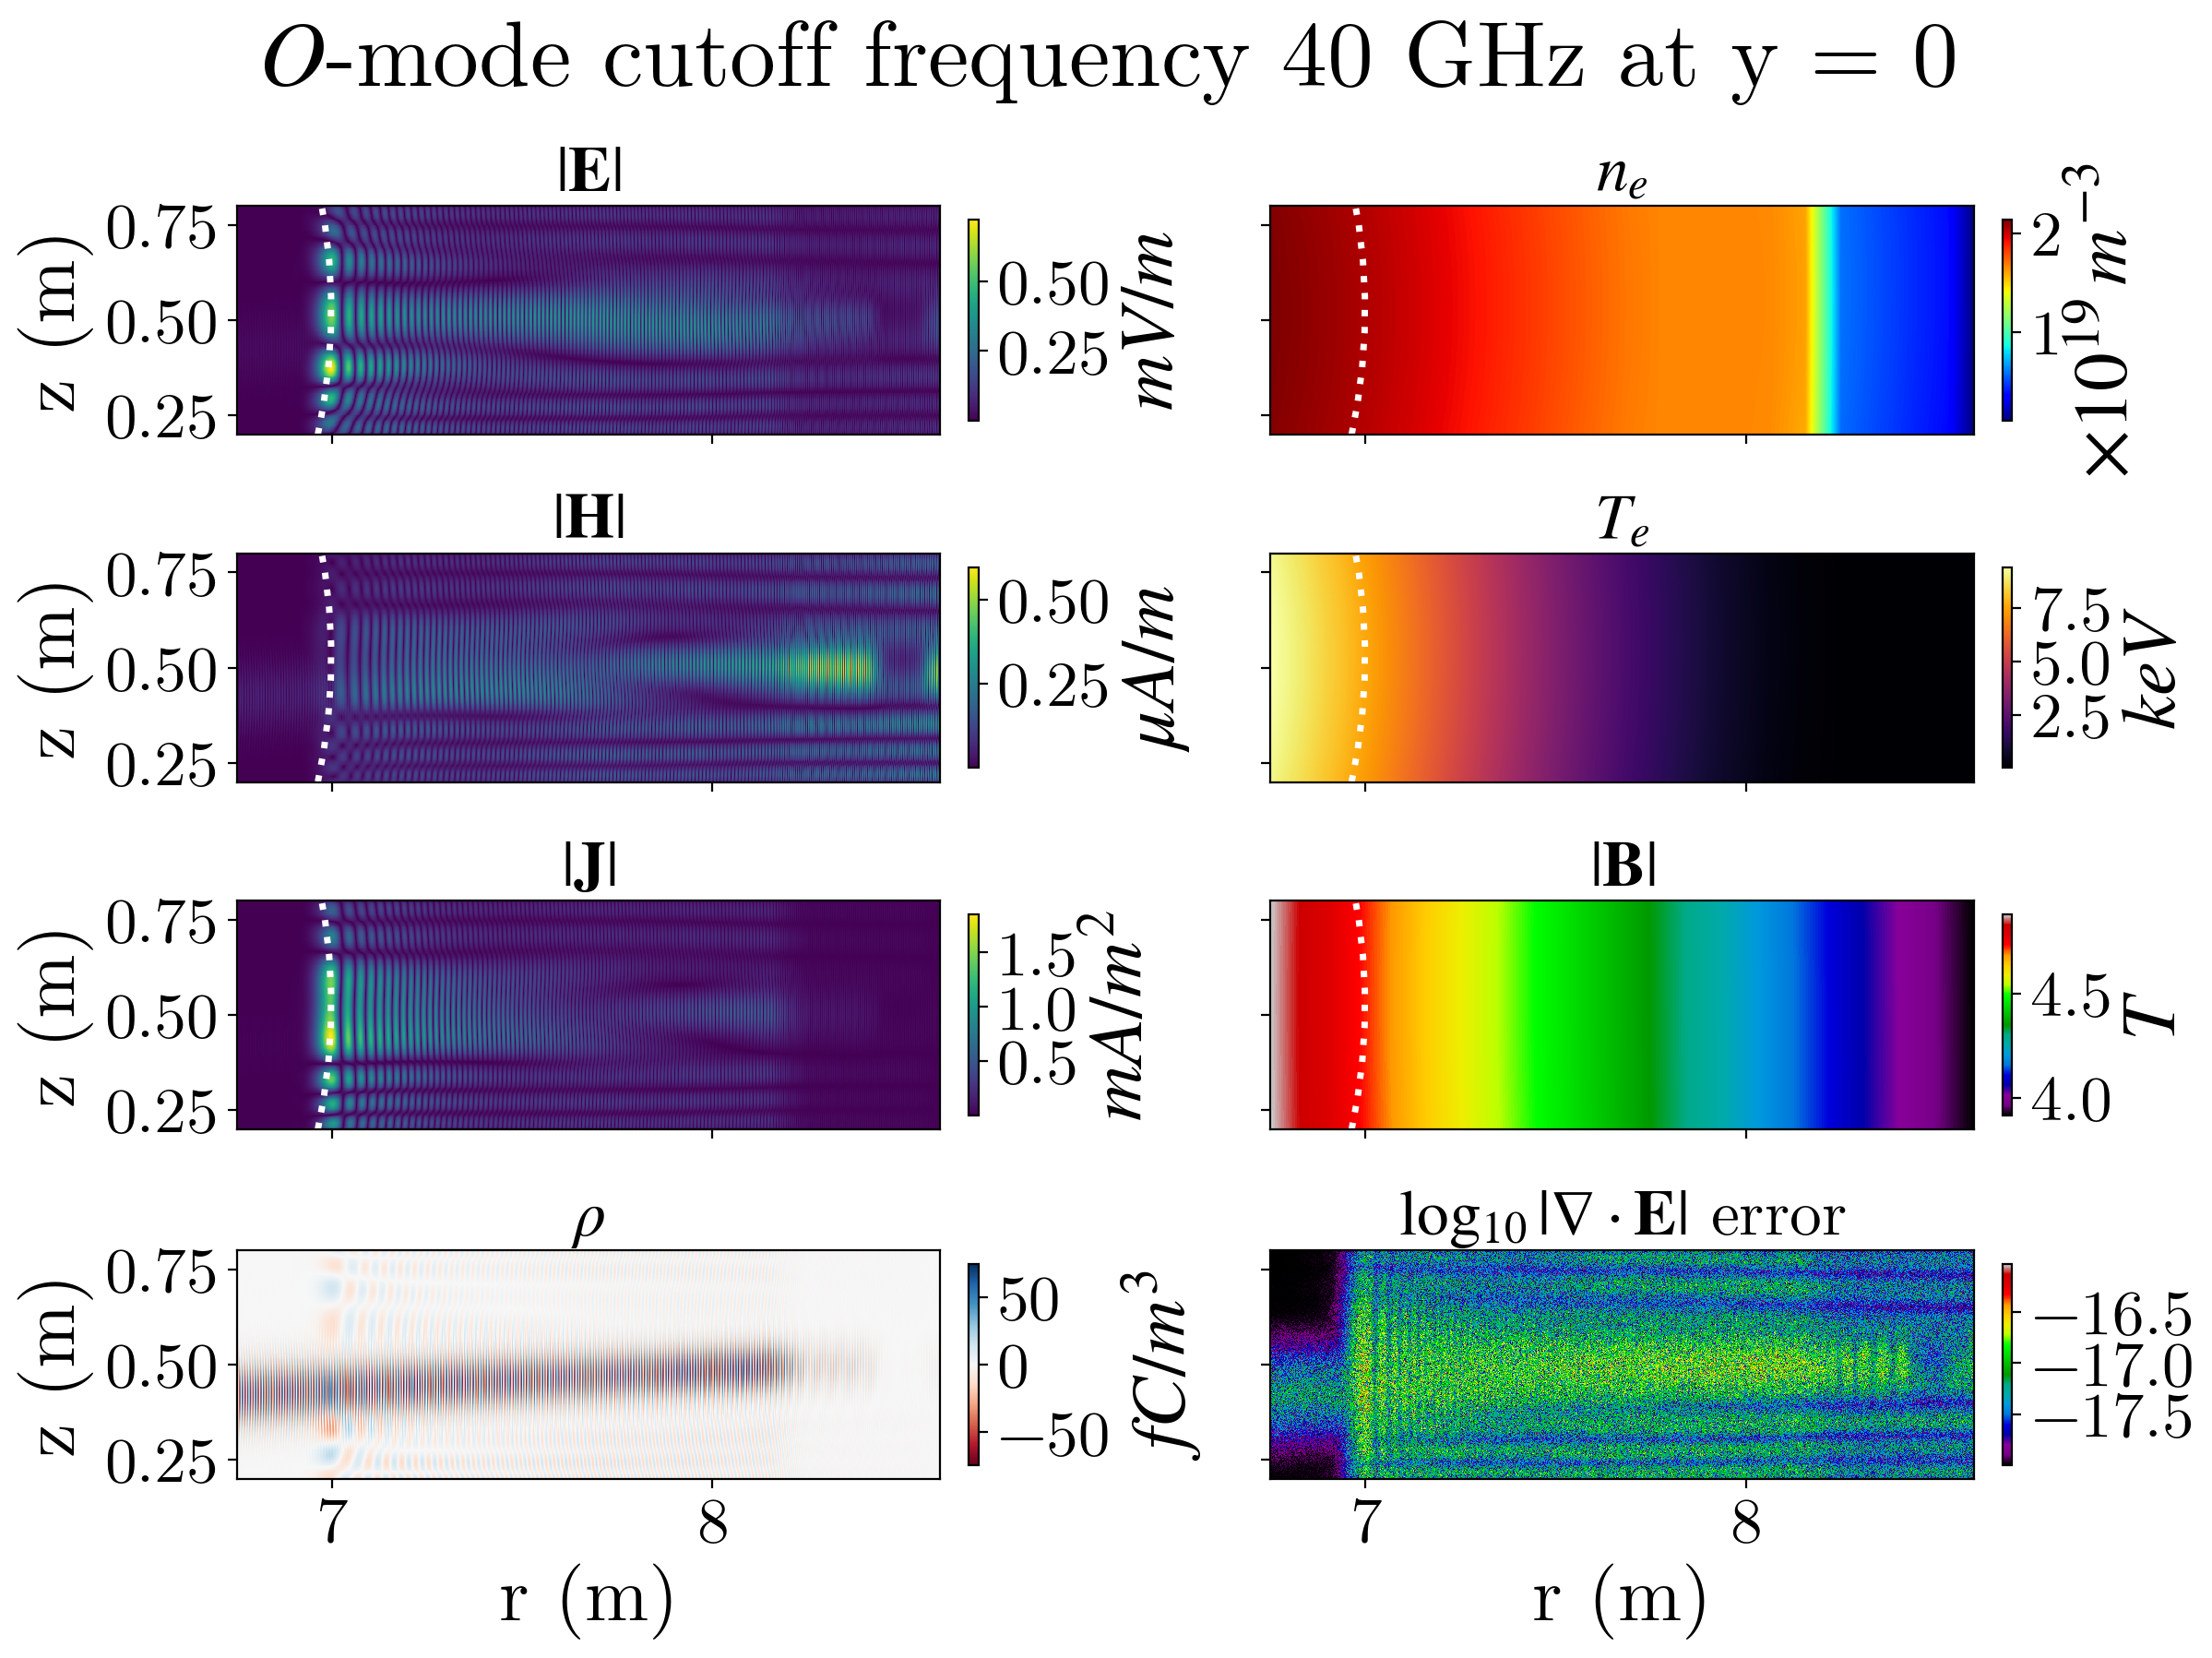

In [24]:
fig, axes = plt.subplots(
    4, 2,
    figsize=(12, 9),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

fig.set_constrained_layout_pads(
    w_pad=0.1,   # horizontal padding between columns, in inches
    h_pad=0.1,   # vertical padding between rows, in inches
    wspace=0.05,  # relative horizontal spacing
    hspace=0.05,  # relative vertical spacing
)

for i in range(4):
    for j in range(2):
        ax = axes[i, j]
        data = plot_data[i][j]
        data_plot = data / plot_scales[i][j]
        
        if plot_center_zero[i][j]:
            # Signed data: force symmetric color scale around 0
            v = np.nanmax(np.abs(data_plot))
        
            if v == 0 or not np.isfinite(v):
                v = 1.0
        
            norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)
        
            im = ax.pcolormesh(
                X[::plot_stride],
                Y[::plot_stride],
                data_plot[::plot_stride],
                shading="auto",
                cmap=plot_cmaps[i][j],
                norm=norm,
                rasterized=True,
            )
        
        else:
            # Non-centered data: generate vmin/vmax automatically
            vmin = np.nanmin(data_plot)
            vmax = np.nanmax(data_plot)
        
            im = ax.pcolormesh(
                X[::plot_stride],
                Y[::plot_stride],
                data_plot[::plot_stride],
                shading="auto",
                cmap=plot_cmaps[i][j],
                vmin=vmin,
                vmax=vmax,
                rasterized=True,
            )            
        fig.colorbar(
            im,
            ax=ax,
            shrink=.75,
            fraction=0.046,
            pad=0.04,
            label=plot_units[i][j],
        )

        # Plot cutoff contour only on the left-hand-side plots:
        # |E|, |H|, |J|
        if i <= 2:
            add_selected_cutoff_contour(ax)

        ax.set_aspect("equal", adjustable="box")
        ax.set_title(plot_titles[i][j])
        
for ax in axes[-1, :]:
    ax.set_xlabel(xlabel)

for ax in axes[:, 0]:
    ax.set_ylabel(ylabel)

plot_title = fr"${cutoff_mode}$-mode cutoff frequency {f_probe_Hz/1e9:.4g} GHz at {axis} = {actual_coord:.4g}"
filename_title = plot_title.replace(" ", "_")
filename_title = filename_title.replace(".", "_")
filename_title = filename_title.replace("$", "")
fig.suptitle(
    # fr"{plotfile}, {axis} = {actual_coord:.4g}",
    plot_title,
    fontsize=36,
)
fig.savefig(f"{filename_title}.png", dpi=800, bbox_inches="tight")
plt.show()